# SRNN Metaplasticity updates

## 1) Introduzione Omeostasi

Omeostasi introdotta come limite nelle risorse neuronali, ovvero le connessioni in entrata ad ogni neurone devono mantenere norma costante ad ogni step di apprendimento.

la norma di riferimento, per ogni neurone, dipende dai valori all'inizializzazione (kaiming norm) e vale circa 

- w_in_neu_norm=19.5 tra input e recurrent
- w_rec_neu_norm=1.39 tra recurrent e recurrent
- w_out_neu_norm=1.82 tra recurrent e output

Ogni singolo neurone ha un proprio valore di target_norm da rispettare ad ogni step di apprendimento.

Si può provare una normalizzazione sul layer invece che sul singolo neurone, piuttosto che su tutte le connessioni della rete, anche se con diversi dubbi sulla bioplausibility dell'idea.




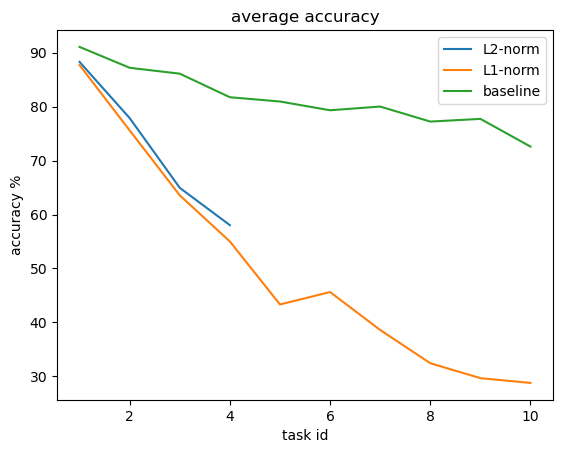

In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt

def get_accs(filename):
    # Pattern: Matches "Raw Accuracy", then any spaces, then captures everything inside []
    pattern = re.compile(r'Domain-IL \s*\[(.*?)\]')
    results = []

    with open(filename, 'r') as file:
        for line in file:
            match = pattern.search(line)
            if match:
                # Extract the string inside brackets and split by comma or space
                values_str = match.group(1)
                # Converts the string values into a list of floats
                values = [float(v.strip()) for v in values_str.replace(',', ' ').split()]
                results.append(values)
    results=results[::2]
    return results


accs_p2=get_accs('output_norms_p2.log')
avg_accs_p2=[np.mean(ldl) for ldl in accs_p2]

accs_p1=get_accs('output_norms_p1.log')
avg_accs_p1=[np.mean(ldl) for ldl in accs_p1]

accs_nofilt=get_accs('output_nofilt.log')
avg_accs_nofilt=[np.mean(ldl) for ldl in accs_nofilt]


accs_nofilt=get_accs('output_nofilt.log')
avg_accs_nofilt=[np.mean(ldl) for ldl in accs_nofilt]

plt.title('average accuracy')
plt.plot(np.arange(1,len(accs_p2)+1),avg_accs_p2,label='L2-norm')
plt.plot(np.arange(1,len(accs_p1)+1),avg_accs_p1,label='L1-norm')
plt.plot(np.arange(1,len(avg_accs_nofilt)+1),avg_accs_nofilt,label='baseline')
plt.legend()
plt.xlabel('task id')
plt.ylabel('accuracy %')
plt.show()


## 2) Analisi Firing Rate Neuroni Ricorrenti



L'analisi è stata effutata utilizzando lo z-score dei firing rate divisi per classe e per task.

Lo z_score di un neuron i, per la task k e classe c è:


$z_{ikc}=\frac{\bar{fr_{ikc}} - mean(\bar{fr_{ik}})} {std(\bar{fr_{ik}})}$

e rappresenta quanto selettivo è un neurone per una certa classe (cifra del mnist) all'interno di una task (nel Domain Incremental Learning, tra una task e l'altra cambia la permutazione dei pixel in input)

Confrontando i 5 neuroni più selettivi per ogni task, emerge che all'interno di ogni task i neuroni sono molto selettivi (0.6% di questi neuroni si sovrappongono tra classi nella stessa task)

Confrontando i 10 neuroni più selettivi per ogni task, il 4.9% di questi neuroni si sovrappongono tra classi nella stessa task 

Analizzando invece se i neuroni specializzati per ogni cifra nella prima task, sono gli stessi specializzati per le corrispondenti classi nelle task successive, emerge una discrepanza:



### 2.1) Top 5 specializzati:

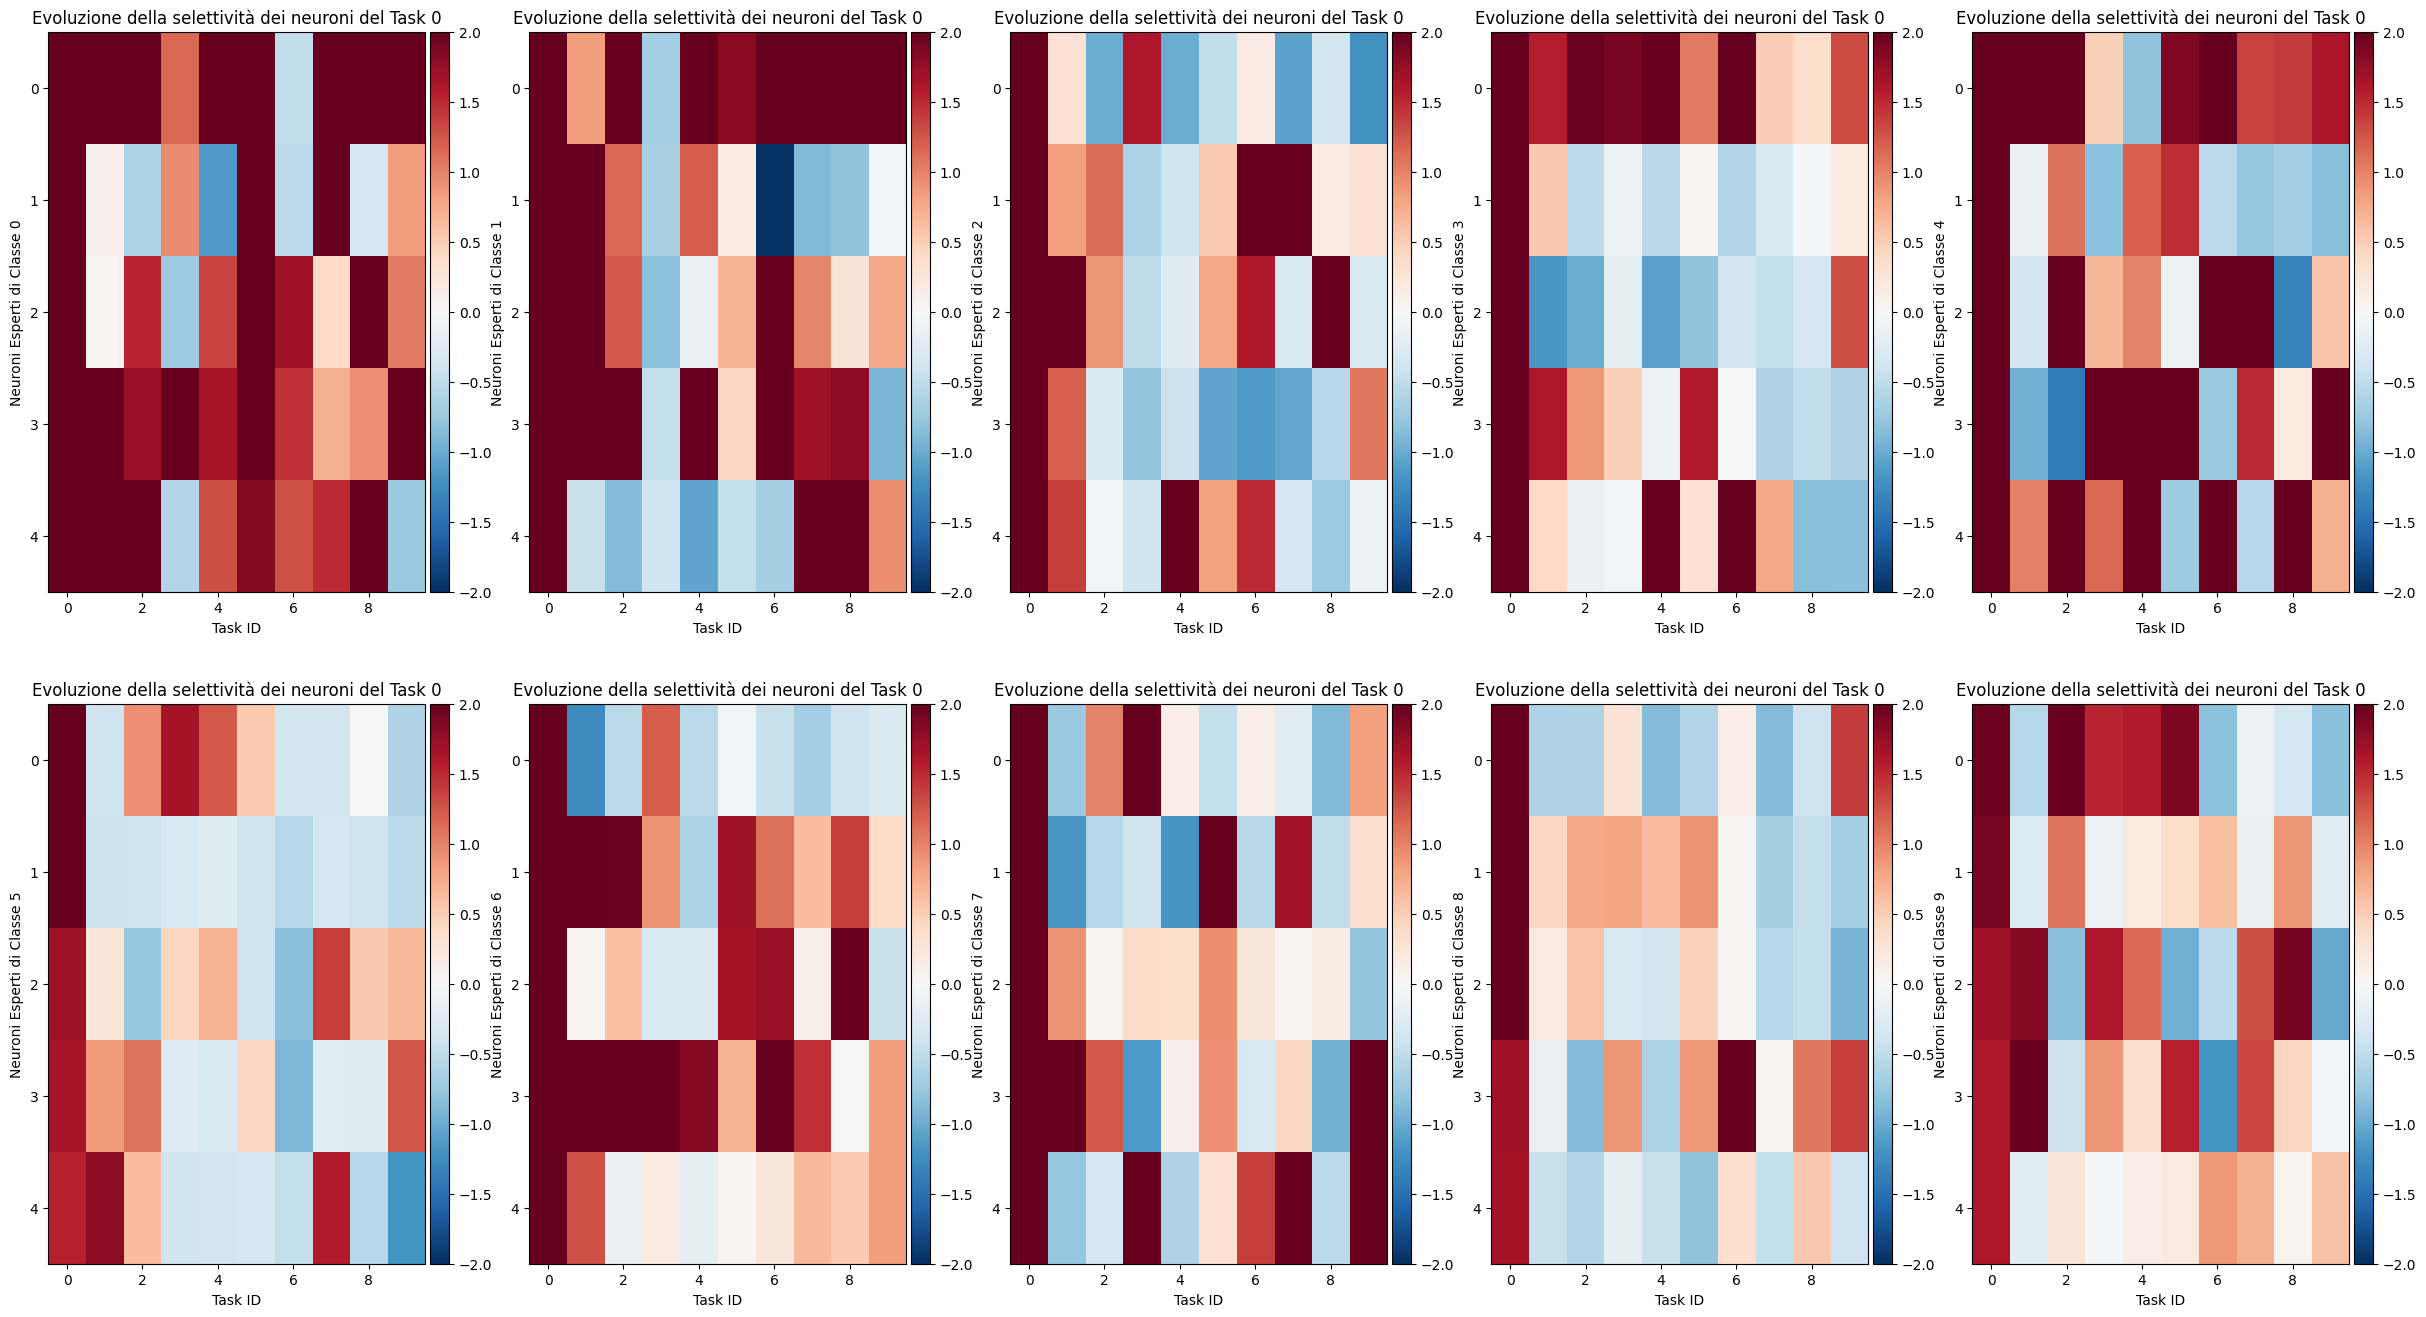

Top 10 specializzati:

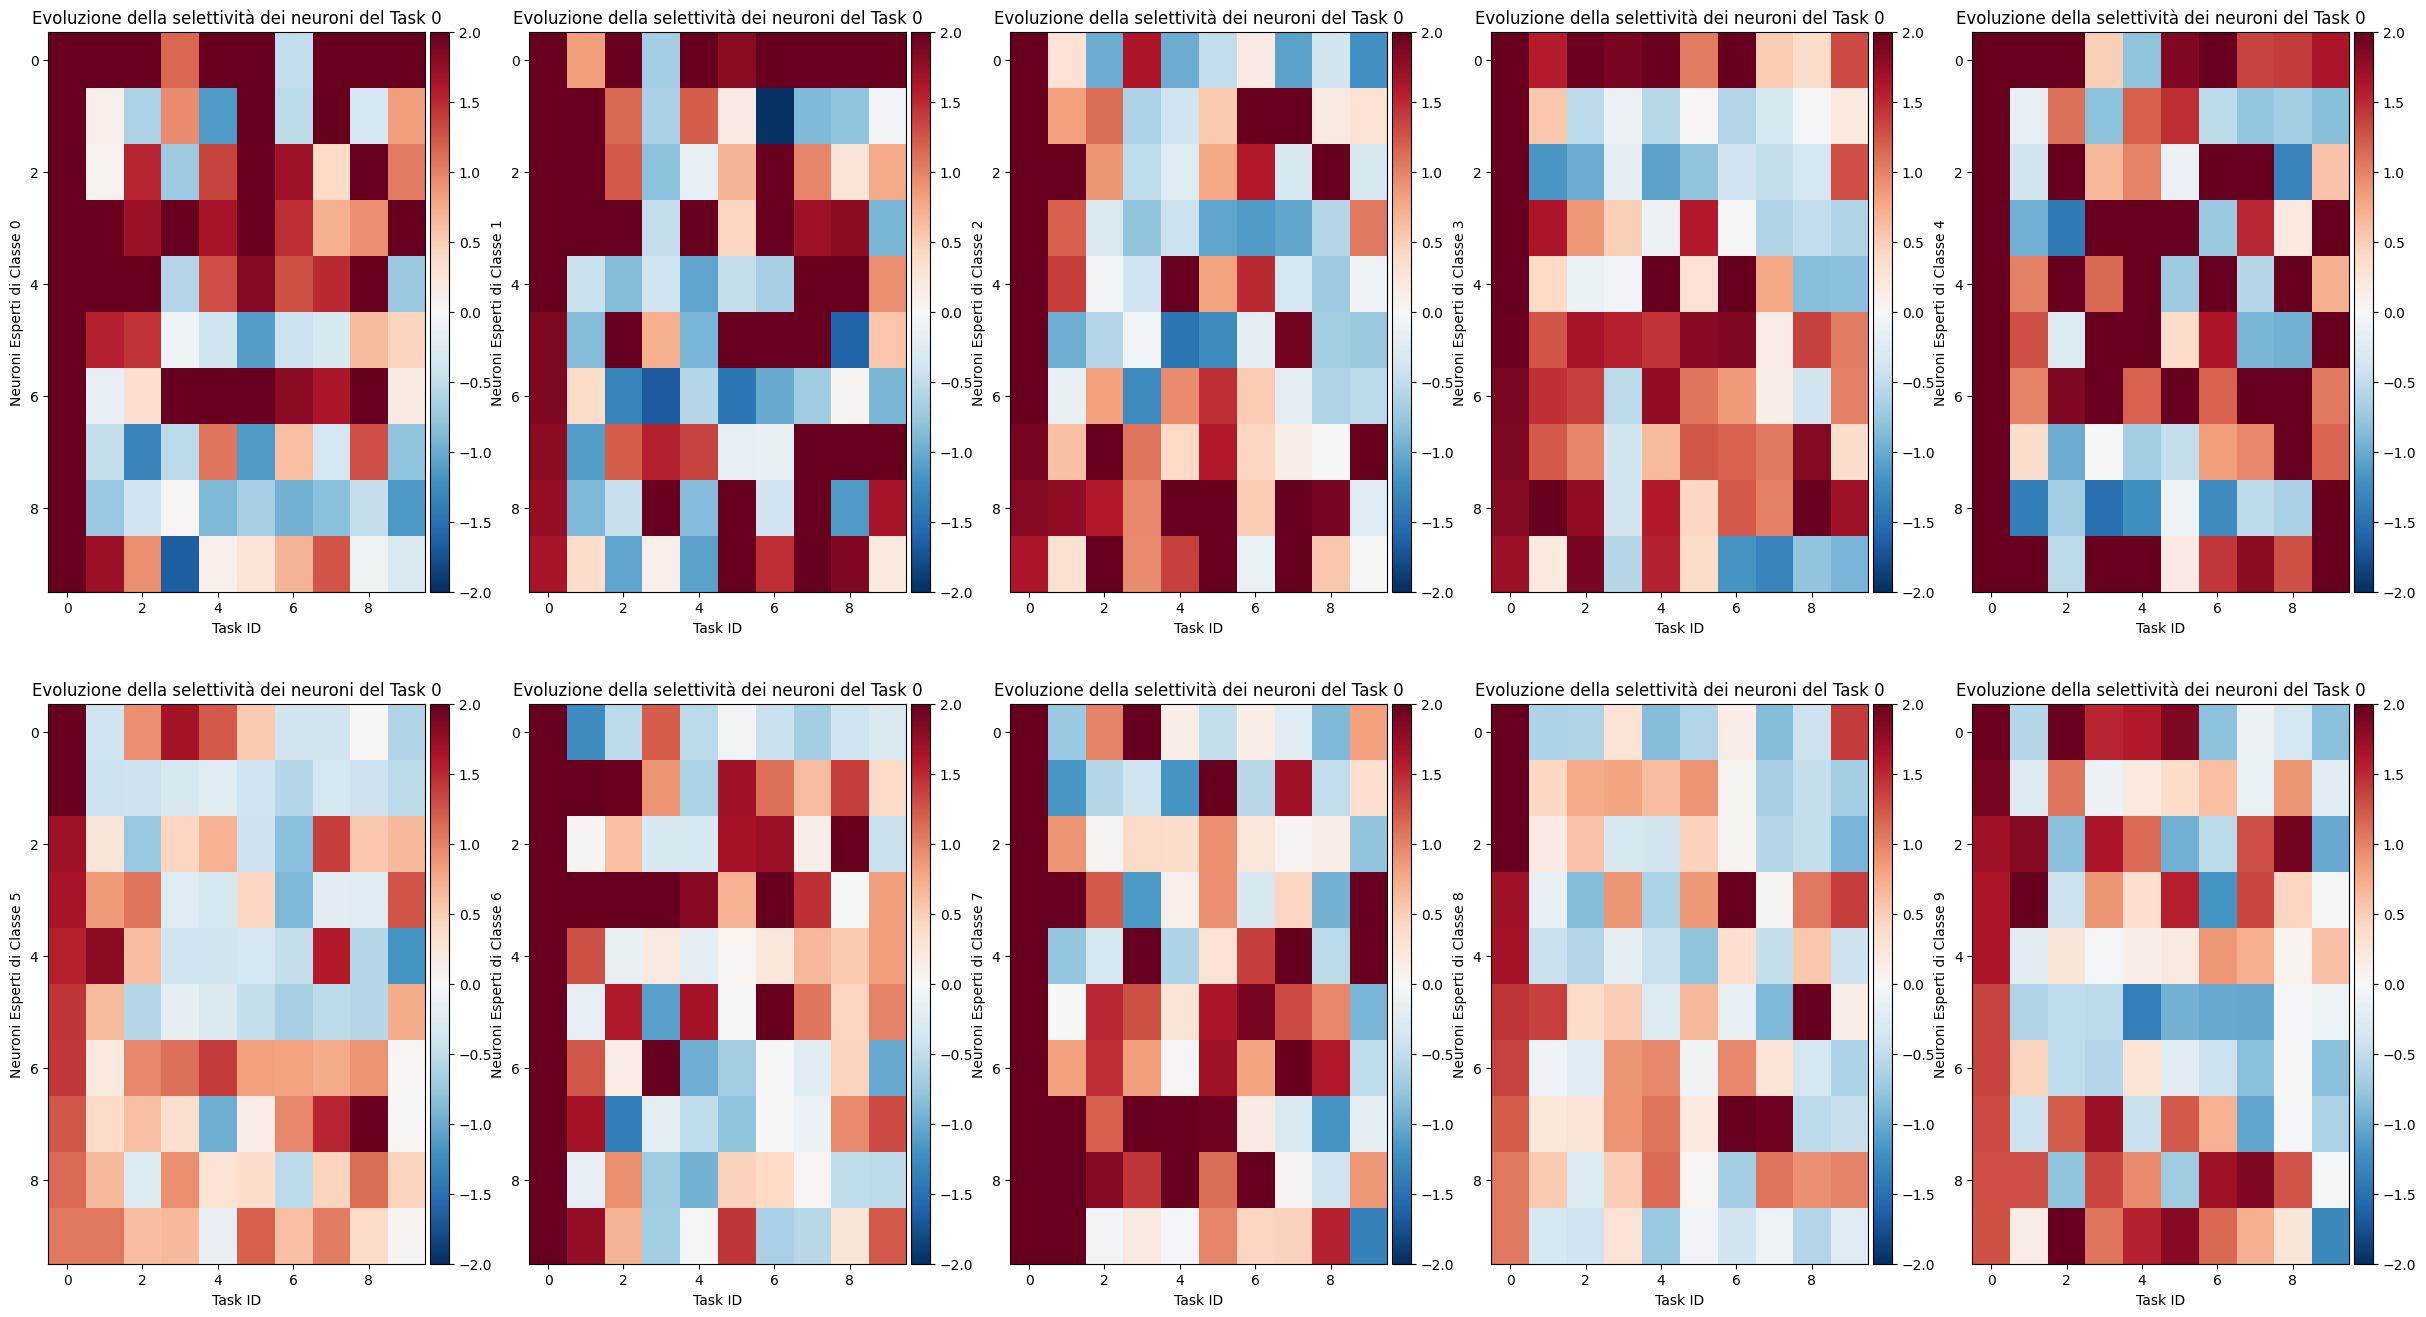

### 2.2) I neuroni si specializzano per rispondere a una classe specifica all'interno di una task?

Clusterizzazione dei neuroni per specializzazione rispetto a una classe (z-score) task per task usando k-means nello spazio delle classi (10D) + PCA per riduzione a 2D per visualizzazione

Tendenzialmente i neuroni tendono a specializzarsi quindi ad avere firing frequency più alta per una classe. Poche eccezzioni si notano, ad esempio, nella task 1 si sovrappongono le classi 3 e 4, 1 e 6, nella task 5 le classi 4 e 9 e nella task 8 le classi 2 e 6. Inoltre ci sono diversi punti che sembrano vicini a centri diversi, probabilmente dovuto alla riduzione di dimensionalità

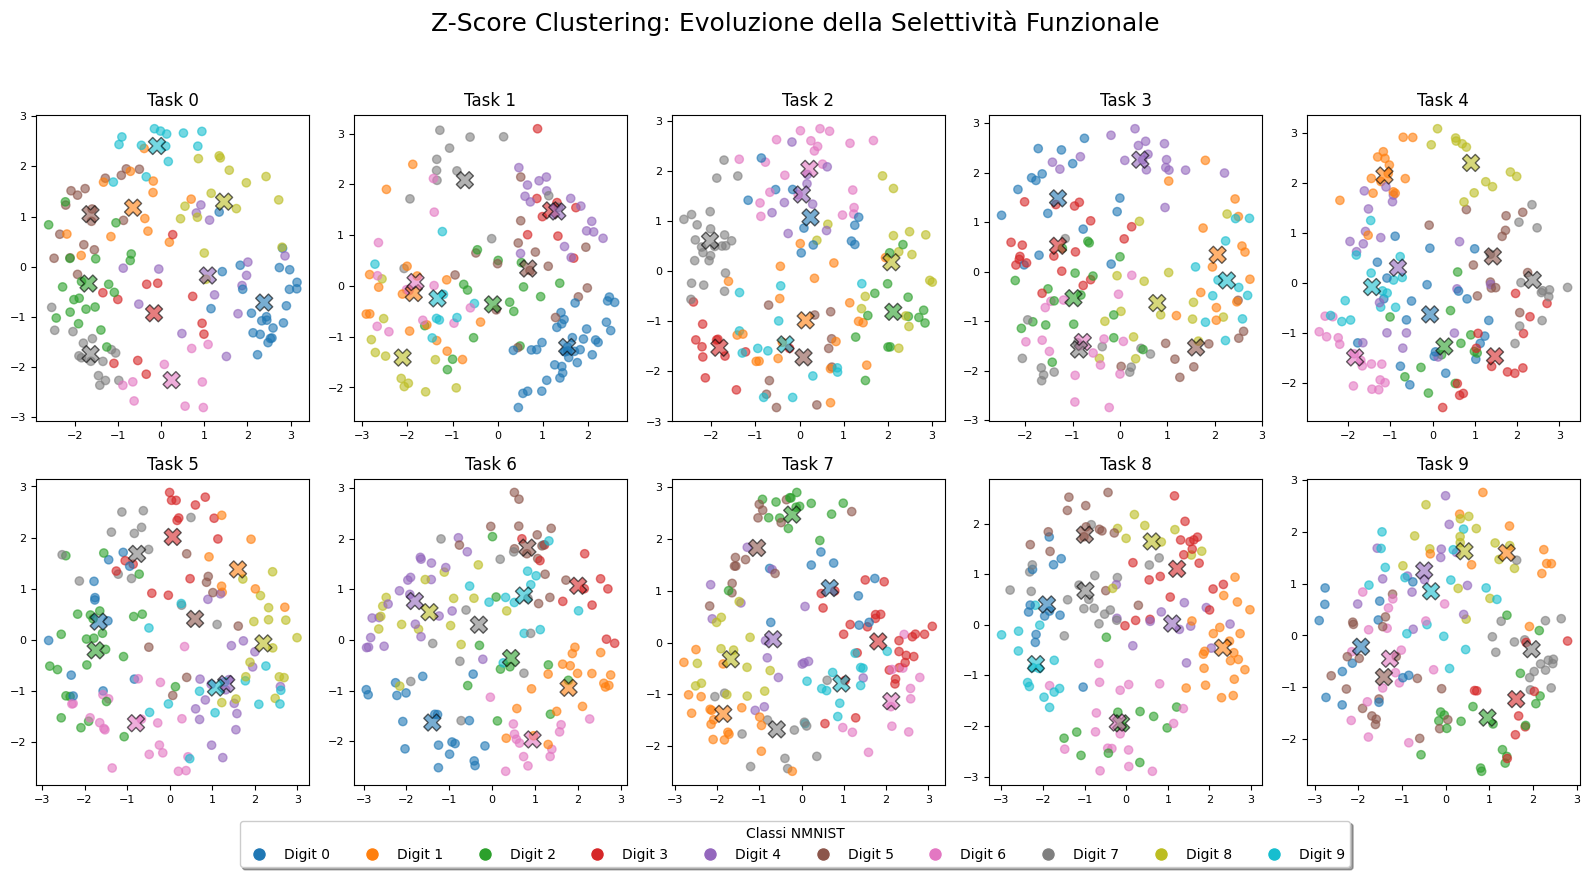

### 2.3) C'è coerenza tra neuroni per la classe x nelle varie task?

Clusterizzazione dei neuroni per specializzazione rispetto a una task (z-score) classe per classe usando k-means nello spazio delle classi (10D) + PCA per riduzione a 2D per visualizzazione


Per quanto si noti una certa sovrapposizione (stessa selettività per la stessa classe in diverse task) si notano comunque molti cluster con centri piuttosto distinti. Questo può esser letto come diversi neuroni si specializzano per la stessa classe in "contesti diversi" ovvero come permutazioni importanti sugli input.

Questa ipotesi è confermata analizzando in 5 neuroni più specializzati (z-score più alto) per classe nelle varie task. In media il 31.8% dei neuroni specializzati in una classe rimangono tali anche in diverse task, decisamente maggiore dello 0.6% di neuroni "condivisi" da 2 classi in ogni task (punto 2.1)

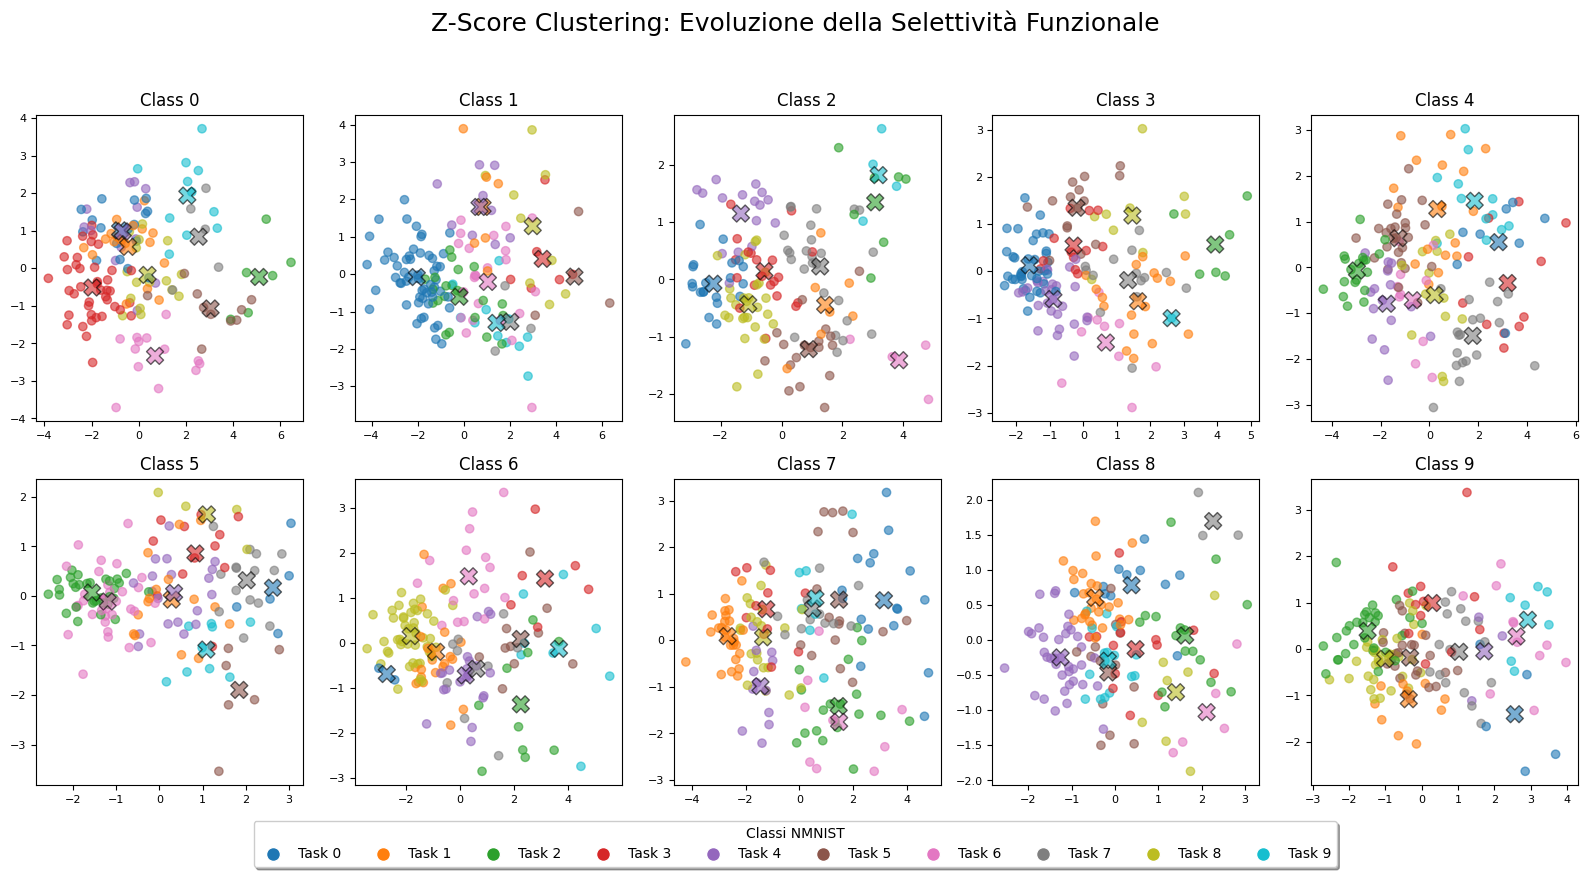



## 3) Rimozione nell'ultima task del Neurone più attivo

Nell'ultima task, si sono azzerati gli spikes dei neuroni con attività media più alta nelle task precedenti per verificarne l'impatto sull'accuracy. Il drop in accuracy risulta drastico già solo rimuovendo il neurone più attivo, peggiorando se più neuroni vengono rimossi


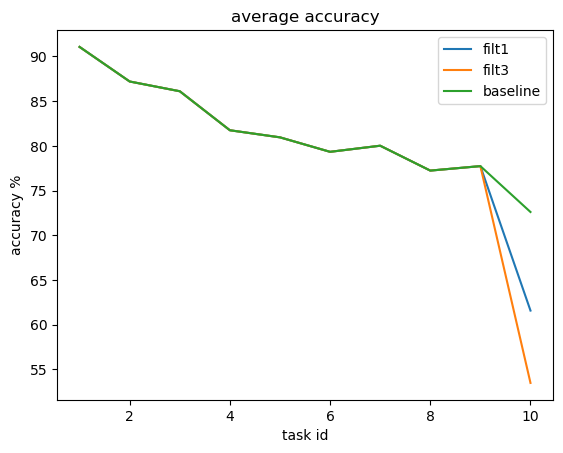

In [4]:

accs_filt1=get_accs('output_filt1.log')
avg_accs_filt1=[np.mean(ldl) for ldl in accs_filt1]

accs_filt3=get_accs('output_filt3.log')
avg_accs_filt3=[np.mean(ldl) for ldl in accs_filt3]
accs_nofilt=get_accs('output_nofilt.log')
avg_accs_nofilt=[np.mean(ldl) for ldl in accs_nofilt]

plt.title('average accuracy')
plt.plot(np.arange(1,len(avg_accs_filt1)+1),avg_accs_filt1,label='filt1')
plt.plot(np.arange(1,len(avg_accs_filt3)+1),avg_accs_filt3,label='filt3')
plt.plot(np.arange(1,len(avg_accs_nofilt)+1),avg_accs_nofilt,label='baseline')
plt.legend()
plt.xlabel('task id')
plt.ylabel('accuracy %')
plt.show()

## 4) Aumento della capacità della rete

Visto l'alta specializzazione dei neuroni per singola task (punto 2.2) e la scarsa specializzazione dei neuroni across task (punto 2.3) ha senso considerare come vincolo del modello la dimensione dello strato ricorrente (quindi la dimensione delle tre matrici di connettivitià W_in, W_rec e W_out).

Una prima stima per la capacità necessaria alla rete potrebbe essere:
n_spec_t=5 neuroni per classe in una task (probabilmente anche di più, visto il 95.7% di specializzazione usando 10 neuroni, punto 2.2)
n_classi=10 digits
p_riuso= 30% neuroni riusati tra una task e la successiva per la stessa classe
n_task=10 (o 20, per exploitare la resistenza all'estremo forgetting della nostra rete)

n_neurons_opt= n_spec**n_classi*p_riuso*n_taskt =5*10*(1-0.3)*10=350 neuroni
            = 10*10*(1-0.3)*20=700 neuroni
idealmente servono tra i 350 e i 700 neuroni ricorrenti.

Provando con 300 neuroni ricorrenti, e mantenendo come tecnica di regolarizzazione la metaplasticità, purtroppo non si notano particolari miglioramenti nell'accuracy


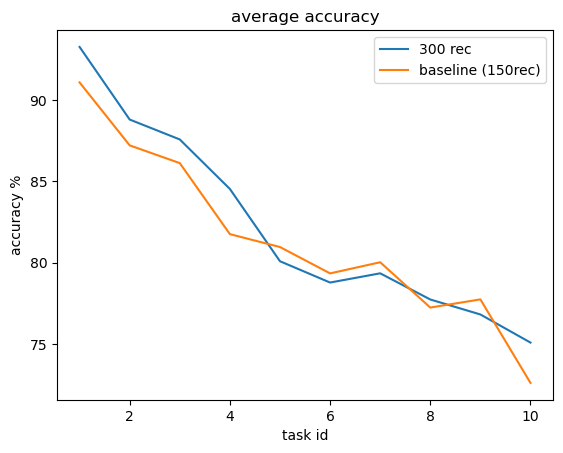

In [6]:

accs_nofilt=get_accs('output_nofilt.log')
avg_accs_nofilt=[np.mean(ldl) for ldl in accs_nofilt]


accs_300rec=get_accs('output_metapl_300rec.log')
avg_accs_300rec=[np.mean(ldl) for ldl in accs_300rec]

plt.title('average accuracy')
plt.plot(np.arange(1,len(avg_accs_300rec)+1),avg_accs_300rec,label='300 rec')
plt.plot(np.arange(1,len(avg_accs_nofilt)+1),avg_accs_nofilt,label='baseline (150rec)')
plt.legend()
plt.xlabel('task id')
plt.ylabel('accuracy %')
plt.show()

## Discussion points:
1) introduzione di filtri per estrazioni di features (line orizzontali, verticali, diagolai, curve ecc)
2) ha senso il perm nmnist per sistemi neuromorfi? uno zero completamente mescolato è ancora uno zero?
3) concetto di assembly o rete funzionale: quanti neuroni servono per classe per task? (stima al punto 4)
4) due gradi di libertà che sto esplorando poco sono: 
    4.1) dimensione del dataset (sto usando il 10% dei dati per il training, visto che comunque ottengo delle performance sopra il 90% sulla singola task. Il motivo principale è il tempo di computazione)
    4.2) numero di epoche, ovvero quante volte faccio vedere i dati di training in ogni task. Espinoza usa 95 epoche per il training e 5 per il test (molto strano honestly). Io sto usando 10 epoche, che alla fine è simile ad usare tutto il dataset con 1 epoca sola (invece che 10 volte il 10% dei dati, userei 1 volta il 100% dei dati)